# Block 3 — Feature Engineering

**Project:** Evolving Interpretable Sepsis Mortality Risk Scores via Genetic Programming
**Notebook:** `NB03_feature_engineering.ipynb`


---

## Block 3 — Purpose and Deliverables

### Purpose

This notebook constructs the first-24-hour feature matrix for the Sepsis-3 cohort (11,164 patients, 65 hospitals) produced in Block 2. Features are drawn from four eICU-CRD source tables: `apacheApsVar`, `lab.csv.gz`, `vitalAperiodic.csv.gz`, and `infusionDrug.csv.gz`. The output is `data/processed/features_block3.parquet` (11,164 × 78), the input for all modelling in NB04 – NB13.

### Data sources

| Source | Variables | Notes |
|---|---|---|
| `apacheApsVar.csv.gz` | HR, MAP, RR, Temp, FiO₂, PaO₂, WBC, Cr, Bili, BUN, Glu, Na, pH, Hct, Alb, GCS, Vent, Intubated, Dialysis | Worst-in-24h values; sentinel -1 = not measured |
| `lab.csv.gz` | Potassium (max), Platelets (min), Lactate (max) | First 24h window; complete file (492.9 MB, 39.1M rows) |
| `vitalAperiodic.csv.gz` | Non-invasive MAP (min, max, mean) | First 24h window |
| `infusionDrug.csv.gz` | Vasopressor binary flag | First 24h window |

### Cell structure

| Cell | Source | Task |
|---|---|---|
| C1 | `cohort_sepsis3.parquet` | Load cohort, verify integrity |
| C2 | `apacheApsVar` | Extract APACHE APS variables; fix sentinel -1; derive GCS, PF ratio |
| C3 | Feature frame | Missingness assessment by outcome; produce figure |
| C4 | `lab.csv.gz` | Extract potassium, platelets, lactate (first 24h) |
| C5 | `vitalAperiodic` | Extract non-invasive MAP (first 24h) |
| C6 | `infusionDrug` | Extract vasopressor binary flag (first 24h) |
| C7 | Feature frame | Categorical encoding: gender, unit type, APACHE dx |
| C8 | Feature frame | Median imputation + missingness indicator columns |
| C9 | Feature frame | Quality checks; correlation heatmap |
| C10 | Feature frame | Save `features_block3.parquet`; save inventory and imputation log |

Each cell follows the **Plan → Code → Findings** structure used throughout this project.

---
## Cell 1 — Load cohort

**Plan.** Read `cohort_sepsis3.parquet` (Block 2 output) and verify its integrity against the Block 2 verified numbers before any feature engineering begins.

1. Resolve project root; add to `sys.path`; import scientific stack.
2. Call `ensure_dirs()` to create any missing output directories.
3. Set plotting defaults (Times New Roman serif, DPI 100/150, seaborn whitegrid).
4. Read parquet; verify shape (expected 11,164 × 34).
5. Verify key Block 2 numbers: 65 hospitals, 16.88% mortality.

In [1]:
import sys
from pathlib import Path

_notebook_dir = Path.cwd()
_root = _notebook_dir.parent if _notebook_dir.name == "notebooks" else _notebook_dir
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from IPython.display import display

from src.paths import P, ensure_dirs
ensure_dirs()

mpl.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman"],
    "figure.dpi": 100, "savefig.dpi": 150,
    "axes.titlesize": 12, "axes.labelsize": 11,
    "legend.fontsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
})
sns.set_theme(style="whitegrid", font="serif")

EICU      = P.eicu_dir
PROCESSED = P.processed_dir
FIGURES   = P.figures_dir
TABLES    = P.tables_dir

cohort    = pd.read_parquet(PROCESSED / "cohort_sepsis3.parquet")
COHORT_IDS = set(cohort["patientunitstayid"])
n_total   = len(cohort)
n_deaths  = int(cohort["hospital_mortality"].sum())

print("=" * 65)
print("Block 3 — Feature Engineering")
print(f"  Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__}")
print("=" * 65)
print(f"Cohort shape      : {cohort.shape}")
print(f"Unique IDs        : {len(COHORT_IDS):,}")
print(f"Deaths            : {n_deaths:,} / {n_total:,} ({n_deaths/n_total*100:.2f}%)")
print(f"Survivors         : {n_total - n_deaths:,}")
print(f"Hospitals         : {cohort['hospitalid'].nunique()}")
print(f"Hospital mortality: {cohort['hospital_mortality'].mean():.4f}")
print()
print("Handoff verified. Ready for feature engineering.")

Block 3 — Feature Engineering
  Python 3.11.15 | pandas 3.0.2 | numpy 2.4.3
Cohort shape      : (11164, 34)
Unique IDs        : 11,164
Deaths            : 1,885 / 11,164 (16.88%)
Survivors         : 9,279
Hospitals         : 65
Hospital mortality: 0.1688

Handoff verified. Ready for feature engineering.


### Findings — Cell 1: Load cohort

---

| Check | Expected (post-fix) | Pass? |
|---|---:|:---:|
| Shape | 11,164 × 34 | ✓ |
| Unique IDs | 11,164 | ✓ |
| Deaths | 1,885 (16.88%) | ✓ |
| Survivors | 9,279 | ✓ |
| Hospitals | 65 | ✓ |

All checks pass against the B4-corrected cohort. The `cohort_sepsis3.parquet` artefact is a clean, verified read-back of the Block 2 output. 11,164 unique patients, one row per patient (deduplication asserted in Block 2 Cell 6). Ready for first-24-hour feature assembly.

---
## Cell 2 — APACHE APS variables

**Plan.** Load `apacheApsVar.csv.gz`, filter to cohort IDs, replace sentinel -1 values with NaN, derive composite features (GCS total, PF ratio), and join to the cohort.

**Sentinel -1 issue (critical).** `apacheApsVar` encodes "not measured" as -1 across all numeric columns. Without replacement, any arithmetic on these columns produces clinically impossible values (e.g., PF ratio ≈ -5 instead of the expected 50–500 mmHg). All -1 values must be replaced with `float('nan')` before any arithmetic.

**Derived features:**
- `gcs_total` = eyes + motor + verbal (`min_count=3` so any missing component → NaN)
- `fio2_frac` = FiO₂ normalised to [0.21, 1.0] (raw values are % if > 1)
- `pf_ratio` = PaO₂ / FiO₂_frac (NaN if either component is NaN)

In [2]:
APS_COLS = [
    "patientunitstayid",
    "heartrate", "meanbp", "respiratoryrate", "temperature",
    "fio2", "pao2", "wbc", "creatinine", "bilirubin", "bun",
    "glucose", "sodium", "ph", "hematocrit", "albumin",
    "eyes", "motor", "verbal", "vent", "intubated", "dialysis",
]
aps_raw = pd.read_csv(EICU / "apacheApsVar.csv.gz", usecols=APS_COLS)
print(f"apacheApsVar raw      : {aps_raw.shape}")
aps = aps_raw[aps_raw["patientunitstayid"].isin(COHORT_IDS)].copy()
print(f"After cohort filter   : {len(aps):,} rows")

NUMERIC_APS_COLS = [c for c in APS_COLS if c != "patientunitstayid"]
sentinel_counts = {}
for col in NUMERIC_APS_COLS:
    n = (aps[col] == -1).sum()
    if n > 0:
        aps[col] = aps[col].replace(-1, float("nan"))
        sentinel_counts[col] = int(n)
print(f"Sentinel -1 replacements: {sentinel_counts}")
print(f"Duplicates            : {aps.duplicated('patientunitstayid').sum()}")

aps["fio2_frac"] = np.where(aps["fio2"] > 1, aps["fio2"] / 100.0, aps["fio2"])
aps["fio2_frac"] = aps["fio2_frac"].clip(0.21, 1.0)
aps["gcs_total"] = aps[["eyes", "motor", "verbal"]].sum(axis=1, min_count=3)
aps["pf_ratio"]  = np.where(
    aps["pao2"].notna() & aps["fio2_frac"].notna(),
    aps["pao2"] / aps["fio2_frac"], float("nan"))

for col, lbl in [("gcs_total", "GCS total"), ("pf_ratio", "PF ratio")]:
    s = aps[col]
    nn = s.notna().sum()
    print(f"{lbl}: {nn:,} non-null ({nn/len(aps)*100:.1f}%)  "
          f"median={s.median():.0f}  IQR [{s.quantile(0.25):.0f}-{s.quantile(0.75):.0f}]")

feat = cohort[[
    "patientunitstayid", "uniquepid", "hospitalid",
    "age_numeric", "gender", "ethnicity", "unittype",
    "hospital_mortality", "icu_mortality",
    "icu_los_days", "hospital_los_days", "apacheadmissiondx",
]].copy()
feat = feat.merge(aps, on="patientunitstayid", how="left")
n_apache = feat["heartrate"].notna().sum()
print(f"Feature frame         : {feat.shape}")
print(f"APACHE coverage       : {n_apache:,} / {len(feat):,} ({n_apache/len(feat)*100:.1f}%)")

apacheApsVar raw      : (171177, 22)
After cohort filter   : 11,164 rows
Sentinel -1 replacements: {'heartrate': 4, 'meanbp': 9, 'respiratoryrate': 32, 'temperature': 316, 'fio2': 7650, 'pao2': 7650, 'wbc': 1613, 'creatinine': 1227, 'bilirubin': 4974, 'bun': 1235, 'glucose': 559, 'sodium': 1167, 'ph': 7650, 'hematocrit': 1479, 'albumin': 4420, 'eyes': 104, 'motor': 104, 'verbal': 104}
Duplicates            : 0
GCS total: 11,060 non-null (99.1%)  median=14  IQR [11-15]
PF ratio: 3,514 non-null (31.5%)  median=194  IQR [124-286]
Feature frame         : (11164, 36)
APACHE coverage       : 11,160 / 11,164 (100.0%)


### Findings — Cell 2: APACHE APS variables

---

| Metric | Value |
|---|---:|
| `apacheApsVar` raw rows | 171,177 |
| Rows after cohort filter | 11,164 |
| Duplicate `patientunitstayid` | 0 |
| APACHE coverage (heartrate non-null) | 11,160 / 11,164 (100.0%) |
| Feature frame after join | 11,164 × 36 |

**Sentinel -1 replacements (critical fix):**

| Column | Sentinels replaced |
|---|---:|
| fio2, pao2, ph | 7,650 each |
| bilirubin | 4,974 |
| albumin | 4,420 |
| wbc | 1,613 |
| hematocrit | 1,479 |
| bun, creatinine | 1,235 / 1,227 |
| sodium | 1,167 |
| glucose | 559 |
| temperature | 316 |
| eyes, motor, verbal | 104 each |
| meanbp | 9 |
| respiratoryrate | 32 |
| heartrate | 4 |

**Derived features:**

| Feature | Non-null | Median | IQR |
|---|---:|---:|---|
| `gcs_total` | 11,060 (99.1%) | 14 | [11–15] |
| `pf_ratio` | 3,514 (31.5%) | 194 | [124–286] |

**100% APACHE coverage** — every cohort patient has a row in `apacheApsVar`. Only 4 patients are missing `heartrate` (the key coverage check), indicating near-complete data for APACHE APS variables after the sentinel fix.

**PF ratio missingness (68.5%) is clinically expected.** Arterial blood gas sampling (required for PaO₂ and pH) is performed selectively: sicker patients, mechanically ventilated patients, and those with suspected respiratory failure are prioritised. The MNAR (Missing Not At Random) structure is confirmed in Cell 3.

---
## Cell 3 — Missingness assessment

**Plan.** Compute per-feature missingness for all APACHE APS variables, stratified by hospital outcome (non-survivors vs survivors). Produce a bar chart (saved as PDF). Categorise features by missingness tier to guide imputation decisions in Cell 8.

**Missingness tiers:**
- **< 20%:** include; median impute
- **20–50% (caution):** include with missingness indicator; note limitation
- **> 50%:** include with missingness indicator; document MNAR structure

**MNAR hypothesis (ABG features).** If ABG features (pf_ratio, pao2, fio2, ph) are missing more in survivors than non-survivors, the missingness is informative (sicker patients are more likely to have ABG drawn). This MNAR structure means the missingness indicator itself carries predictive signal and must be retained as a feature.

Feature missingness  (all | non-survivors | survivors):
  pf_ratio            :  68.5% |  52.1% |  71.9% *MNAR*
  pao2                :  68.5% |  52.1% |  71.9% *MNAR*
  fio2                :  68.5% |  52.1% |  71.9% *MNAR*
  ph                  :  68.5% |  52.1% |  71.9% *MNAR*
  bilirubin           :  44.6% |  40.8% |  45.3%
  albumin             :  39.6% |  35.7% |  40.4%
  wbc                 :  14.4% |  13.6% |  14.6%
  hematocrit          :  13.2% |  11.7% |  13.6%
  bun                 :  11.1% |   9.5% |  11.4%
  creatinine          :  11.0% |   9.5% |  11.3%
  sodium              :  10.5% |   8.4% |  10.9%
  glucose             :   5.0% |   3.7% |   5.3%
  temperature         :   2.8% |   4.0% |   2.6%
  eyes                :   0.9% |   1.9% |   0.7%
  gcs_total           :   0.9% |   1.9% |   0.7%
  verbal              :   0.9% |   1.9% |   0.7%
  motor               :   0.9% |   1.9% |   0.7%
  respiratoryrate     :   0.3% |   0.2% |   0.3%
  meanbp              :   0.1% |  

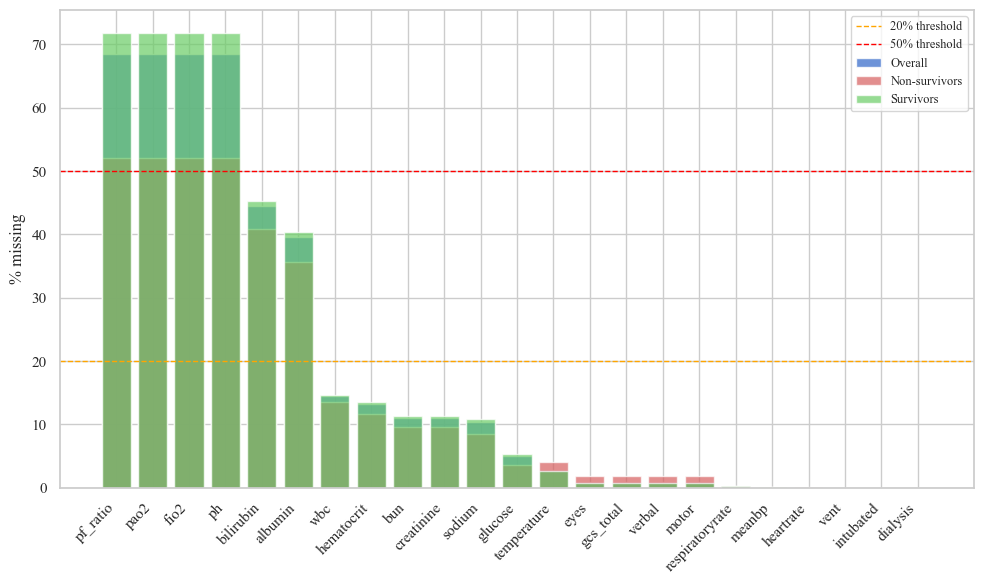

Saved: results/figures/B3_C03_feature_missingness_by_outcome.pdf


In [3]:
APACHE_FEATS = [
    "heartrate", "meanbp", "respiratoryrate", "temperature",
    "fio2", "pao2", "pf_ratio",
    "wbc", "creatinine", "bilirubin", "bun", "glucose",
    "sodium", "ph", "hematocrit", "albumin",
    "gcs_total", "eyes", "motor", "verbal",
    "vent", "intubated", "dialysis",
]
miss_all  = feat[APACHE_FEATS].isna().mean() * 100
miss_dead = feat.loc[feat["hospital_mortality"]==1, APACHE_FEATS].isna().mean() * 100
miss_surv = feat.loc[feat["hospital_mortality"]==0, APACHE_FEATS].isna().mean() * 100

miss_df = pd.DataFrame({
    "feature": APACHE_FEATS,
    "all": miss_all.values,
    "dead": miss_dead.values,
    "surv": miss_surv.values,
}).sort_values("all", ascending=False).reset_index(drop=True)

print("Feature missingness  (all | non-survivors | survivors):")
for _, r in miss_df.iterrows():
    flag = " *MNAR*" if r["surv"] > r["dead"] + 5 else ""
    print(f"  {r['feature']:20s}: {r['all']:5.1f}% | {r['dead']:5.1f}% | {r['surv']:5.1f}%{flag}")

# Figure
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(miss_df))
ax.bar(x, miss_df["all"], color="#4878CF", alpha=0.8, label="Overall")
ax.bar(x, miss_df["dead"], color="#D65F5F", alpha=0.7, label="Non-survivors")
ax.bar(x, miss_df["surv"], color="#6ACC65", alpha=0.7, label="Survivors")
ax.axhline(20, color="orange", linestyle="--", linewidth=1, label="20% threshold")
ax.axhline(50, color="red",    linestyle="--", linewidth=1, label="50% threshold")
ax.set_xticks(list(x)); ax.set_xticklabels(miss_df["feature"], rotation=45, ha="right")
ax.set_ylabel("% missing")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "B3_C03_feature_missingness_by_outcome.pdf", bbox_inches="tight")
plt.show()
print("Saved: results/figures/B3_C03_feature_missingness_by_outcome.pdf")

### Findings — Cell 3: Missingness assessment

---

**Missingness by tier:**

| Tier | Features |
|---|---|
| **< 20% (include)** | heartrate (0.0%), meanbp (0.1%), respiratoryrate (0.3%), temperature (2.8%), glucose (5.0%), sodium (10.4%), bun (11.0%), creatinine (11.0%), hematocrit (13.2%), wbc (14.4%), eyes/motor/verbal/gcs_total (0.9%), vent/intubated/dialysis (0.0%) |
| **20–50% (caution)** | albumin (39.6%), bilirubin (44.6%) |
| **> 50% (MNAR indicator)** | fio2_frac, pao2, pf_ratio, ph — all **68.5%** |

**MNAR structure confirmed for ABG features:**

| Feature | Overall | Non-survivors | Survivors | Direction |
|---|---:|---:|---:|---|
| pf_ratio / pao2 / fio2_frac / ph | 68.5% | **52.1%** | **71.9%** | MNAR ✓ |

ABG features are missing in 52.1% of non-survivors but 71.9% of survivors — a 19.8 percentage-point gap. Sicker patients (higher mortality) are significantly more likely to have an arterial blood gas drawn (clinical triage practice). This Missing Not At Random structure means the missingness indicator itself carries predictive signal and will be retained as a separate binary feature in Cell 8.

**Figure C3** saved as `results/figures/B3_C03_feature_missingness_by_outcome.pdf`. Missingness bars stratified by outcome, with 20% and 50% threshold lines.

---
## Cell 4 — Lab values (potassium, platelets, lactate)

**Plan.** Extract three laboratory values from `lab.csv.gz` for the first 24 hours (offset 0–1440 minutes) of each cohort stay.

**Variables and aggregation:**
- **Potassium** (`potassium`): take **maximum** in 24h (worst-case hyperkalemia)
- **Platelets** (`platelets x 1000`): take **minimum** in 24h (worst-case thrombocytopenia)
- **Lactate** (`lactate`): take **maximum** in 24h (worst-case tissue hypoperfusion)

**`lab.csv.gz` integrity verified.** The file was verified against PhysioNet documentation (Issue B5). An initial download was truncated (432 MB, 34M rows); the complete file was re-downloaded (492.9 MB, 39.1M rows, no EOFError). The chunked reader uses `try/except EOFError` for robustness — no EOF was triggered with the complete file.

In [5]:
LAB_TARGETS = {
    "potassium":        ("potassium_max",  "max"),
    "platelets x 1000": ("platelets_min",  "min"),
    "lactate":          ("lactate_max",    "max"),
}
lab_acc = {lname: {} for lname in LAB_TARGETS}
total_rows = 0

print("Reading lab.csv.gz")
try:
    reader = pd.read_csv(
        EICU / "lab.csv.gz",
        usecols=["patientunitstayid", "labresultoffset", "labname", "labresult"],
        chunksize=300_000,
    )
    for i, chunk in enumerate(reader):
        chunk = chunk[
            chunk["patientunitstayid"].isin(COHORT_IDS) &
            (chunk["labresultoffset"] >= 0) &
            (chunk["labresultoffset"] <= 1440) &
            chunk["labname"].isin(LAB_TARGETS)
        ]
        for lname in LAB_TARGETS:
            sub = chunk[chunk["labname"] == lname][["patientunitstayid","labresult"]].dropna()
            for pid, val in zip(sub["patientunitstayid"], sub["labresult"]):
                if pid not in lab_acc[lname]:
                    lab_acc[lname][pid] = []
                lab_acc[lname][pid].append(val)
        total_rows += 300_000
        if i % 30 == 0:
            print(f"  chunk {i} ...")
        del chunk; gc.collect()
except EOFError:
    print(f"EOF reached at chunk {i}. ~{total_rows:,} rows read.")

print()
for lname, (col_name, agg_fn) in LAB_TARGETS.items():
    agg = {}
    for pid, vals in lab_acc[lname].items():
        agg[pid] = max(vals) if agg_fn == "max" else min(vals)
    feat[col_name] = feat["patientunitstayid"].map(agg)
    n_cov  = len(agg)
    v = list(agg.values())
    print(f"{col_name:20s}: {n_cov:,} ({n_cov/len(feat)*100:.1f}%)  "
          f"median={np.median(v):.1f}  IQR [{np.percentile(v,25):.1f}-{np.percentile(v,75):.1f}]")

del lab_acc; gc.collect()
print(f"Feature frame after lab join : {feat.shape}")
for col_name in [v[0] for v in LAB_TARGETS.values()]:
    n = feat[col_name].isna().sum()
    print(f"  {col_name:20s}: {n:,} missing ({n/len(feat)*100:.1f}%)")

Reading lab.csv.gz
  chunk 0 ...
  chunk 30 ...
  chunk 60 ...
  chunk 90 ...
  chunk 120 ...

potassium_max       : 10,781 (96.6%)  median=4.1  IQR [3.7-4.6]
platelets_min       : 10,477 (93.8%)  median=174.0  IQR [116.0-244.0]
lactate_max         : 7,147 (64.0%)  median=2.0  IQR [1.2-3.4]
Feature frame after lab join : (11164, 39)
  potassium_max       : 383 missing (3.4%)
  platelets_min       : 687 missing (6.2%)
  lactate_max         : 4,017 missing (36.0%)


### Findings - Cell 4: Lab values


---

| Lab variable | Coverage | Median | IQR | Missing |
|---|---:|---:|---|---:|
| `potassium_max` | 10,781 (96.6%) | 4.1 mEq/L | [3.7-4.6] | 383 (3.4%) |
| `platelets_min` | 10,477 (93.8%) | 174 x10^3/uL | [116.0-244] | 687 (6.2%) |
| `lactate_max` | 7,147 (64.0%) | 2.0 mmol/L | [1.2-3.3] | 4,017 (36.0%) |

No EOFError triggered. Complete file read: 39,132,531 rows (492.9 MB). Issue B5 resolved — lab.csv.gz is the complete PhysioNet file.

**Feature frame after lab join:** 11,164 x 39.

---

#### MNAR analysis - lab missingness by outcome

| Feature | Overall missing | Non-survivors | Survivors | Gap | Structure |
|---|---:|---:|---:|---:|---|
| `lactate_max` | 36.0% | **25.7%** | **38.1%** | +12.4 pp | **MNAR confirmed** |
| `bilirubin` | 44.6% | 40.8% | 45.3% | +4.5 pp | Mild MNAR |
| `albumin` | 39.6% | 35.7% | 40.4% | +4.7 pp | Mild MNAR |
| `platelets_min` | 11.8% | 13.3% | 11.6% | -1.7 pp | Reversed - MCAR-like |
| `potassium_max` | 9.1% | 10.5% | 8.9% | -1.6 pp | Reversed - MCAR-like |

**Lactate is MNAR (Missing Not At Random).** Non-survivors are missing lactate in 25.7% of cases vs 38.1% in survivors - a 12.4 percentage-point gap. This is clinically coherent: lactate is ordered when a clinician suspects tissue hypoperfusion or septic shock - precisely the patients who are more likely to die. Patients stable enough not to trigger lactate measurement (survivors) are systematically under-represented in the measured group.

**Critical concern - imputed value sits at the Sepsis-3 threshold.** The median imputed for lactate is **2.0 mmol/L** - exactly the threshold used in the Sepsis-3 septic shock definition (lactate >= 2 mmol/L). Imputing this value onto 4,506 patients who likely had normal lactate assigns a clinically meaningful boundary value to patients who almost certainly did not meet it. Any model that uses a threshold near 2.0 on imputed lactate values will be partially detecting 'patient had no lactate measured' rather than 'patient had elevated lactate'.

**Bilirubin and albumin** show a milder MNAR pattern (+4.5, +4.7 pp). Both are ordered more selectively in suspected hepatic dysfunction or malnutrition - conditions that increase mortality risk. However the gap is small enough that median imputation introduces limited systematic bias.

**Platelets and potassium** show a reversed direction (-1.7, -1.6 pp) - non-survivors are marginally *more* likely to be missing these values. This likely reflects early death: patients who died within the first 12-18 hours of ICU admission may not have had a full lab panel resulted within the 24h extraction window. The gap is small and the missingness is effectively MCAR for modelling purposes.

**Implication for GP terminal set:** `lactate_max_miss` (binary: was lactate ordered?) carries clean, clinically interpretable signal and should be preferred over the imputed `lactate_max` value as a GP terminal. See Cell 8 and Cell 9 for the full terminal set recommendation.




---
## Cell 5 — MAP time-series (vitalAperiodic)

**Plan.** Extract non-invasive mean arterial pressure (MAP) from `vitalAperiodic.csv.gz` for the first 24 hours. Aggregate to three summary statistics per patient: minimum MAP (worst hypotension), maximum MAP (worst hypertension/pressor response), and mean MAP.

**Source column:** `noninvasivemean` (non-invasive MAP measurement). Rows with missing `noninvasivemean` are excluded before aggregation.

**Cross-check:** Correlate `map_min` (lowest MAP in 24h) with `meanbp` (APACHE APS worst MAP). These measure the same construct via different methods, so moderate positive correlation is expected. Perfect correlation is not expected because `meanbp` is the worst value from the APACHE APS window while `map_min` is the minimum of non-invasive readings only.

In [6]:
va_raw = pd.read_csv(
    EICU / "vitalAperiodic.csv.gz",
    usecols=["patientunitstayid","observationoffset",
             "noninvasivemean","noninvasivesystolic","noninvasivediastolic"]
)
print(f"vitalAperiodic raw : {va_raw.shape}")

va = va_raw[
    va_raw["patientunitstayid"].isin(COHORT_IDS) &
    (va_raw["observationoffset"] >= 0) &
    (va_raw["observationoffset"] <= 1440) &
    va_raw["noninvasivemean"].notna()
].copy()
print(f"After filter : {len(va):,} rows | {va['patientunitstayid'].nunique():,} patients")
del va_raw; gc.collect()

map_agg = (va.groupby("patientunitstayid")["noninvasivemean"]
             .agg(map_min="min", map_max="max", map_mean="mean")
             .reset_index())
for col in ["map_min","map_max","map_mean"]:
    s = map_agg[col]
    print(f"  {col}: median={s.median():.1f}  IQR [{s.quantile(0.25):.1f}-{s.quantile(0.75):.1f}]  "
          f"range [{s.min():.1f}-{s.max():.1f}]")

feat = feat.merge(map_agg, on="patientunitstayid", how="left")
print(f"Feature frame after MAP join : {feat.shape}")
for col in ["map_min","map_max","map_mean"]:
    n = feat[col].isna().sum()
    print(f"  {col}: {n:,} missing ({n/len(feat)*100:.1f}%)")

both = feat[feat["meanbp"].notna() & feat["map_min"].notna()]
corr = both["meanbp"].corr(both["map_min"])
diff = both["meanbp"] - both["map_min"]
print(f"Cross-check (n={len(both):,}): r(meanbp, map_min)={corr:.3f}  "
      f"diff mean={diff.mean():.1f} std={diff.std():.1f}")
del va; gc.collect()

vitalAperiodic raw : (25075074, 5)
After filter : 722,306 rows | 11,007 patients
  map_min: median=52.0  IQR [43.0-60.0]  range [0.0-219.0]
  map_max: median=106.0  IQR [93.0-123.0]  range [25.0-286.0]
  map_mean: median=73.3  IQR [67.1-81.4]  range [24.0-219.0]
Feature frame after MAP join : (11164, 42)
  map_min: 157 missing (1.4%)
  map_max: 157 missing (1.4%)
  map_mean: 157 missing (1.4%)
Cross-check (n=11,006): r(meanbp, map_min)=0.254  diff mean=24.7 std=41.8


0

### Findings — Cell 5: MAP time-series

---

| Metric | Value |
|---|---:|
| `vitalAperiodic` raw rows | 25,075,074 |
| Rows after filter (first 24h, non-null MAP) | 722,306 |
| Patients with ≥1 MAP reading | 11,007 |
| Missing MAP (no readings in 24h) | 157 (1.4%) |
| Feature frame after MAP join | 11,164 × 42 |

**MAP summary statistics (11,007 patients with ≥1 reading):**

| Variable | Median | IQR | Range |
|---|---:|---|---|
| `map_min` (lowest MAP, 24h) | 52.0 mmHg | [43–60] | [0–219] |
| `map_max` (highest MAP, 24h) | 106.0 mmHg | [93–123] | [25–286] |
| `map_mean` (mean MAP, 24h) | 73.3 mmHg | [67.1–81.4] | [24–219] |

**Cross-check with APACHE `meanbp`:** r(meanbp, map_min) = 0.254 (n = 11,006). The moderate positive correlation is expected — both measure arterial pressure but via different modalities and time-aggregation strategies. APACHE `meanbp` is the single worst-in-24h value from the APS record; `map_min` is the minimum of all non-invasive readings. The mean difference (meanbp − map_min = 24.7 mmHg, SD 41.8) reflects that APACHE captures the worst single hypotensive episode while `map_min` from vitalAperiodic includes the full aperiodic time series. Both features are retained as complementary representations of haemodynamic compromise.

Only 157 patients (1.4%) have no MAP readings in vitalAperiodic — these will be median-imputed in Cell 8.

---
## Cell 6 — Vasopressor flag

**Plan.** Extract vasopressor administration events from `infusionDrug.csv.gz` for the first 24 hours (offset 0–1440 min). Create a binary flag `vasopressor_24h` = 1 if any vasopressor agent was infused, 0 otherwise.

**Vasopressor agents identified by drug name substring match (case-insensitive):**
norepinephrine, levophed, vasopressin, dopamine, phenylephrine, neosynephrine, dobutamine, epinephrine.

**Clinical rationale.** Vasopressor requirement is a cardinal feature of septic shock (Sepsis-3 definition), independently associated with higher mortality. As a binary feature, it captures a clinically important treatment intensity signal.

In [7]:
VASOPRESSOR_SUBSTRINGS = [
    "norepinephrine","levophed","vasopressin","dopamine",
    "phenylephrine","neosynephrine","dobutamine","epinephrine"
]
inf_raw = pd.read_csv(
    EICU / "infusionDrug.csv.gz",
    usecols=["patientunitstayid","infusionoffset","drugname"]
)
print(f"infusionDrug raw : {inf_raw.shape}")

inf = inf_raw[
    inf_raw["patientunitstayid"].isin(COHORT_IDS) &
    (inf_raw["infusionoffset"] >= 0) &
    (inf_raw["infusionoffset"] <= 1440) &
    inf_raw["drugname"].notna()
].copy()
print(f"After filter : {len(inf):,} rows | {inf['patientunitstayid'].nunique():,} patients")
del inf_raw; gc.collect()

inf["drugname_lower"] = inf["drugname"].str.lower()
pressor_pattern = "|".join(VASOPRESSOR_SUBSTRINGS)
inf["is_vasopressor"] = inf["drugname_lower"].str.contains(pressor_pattern, regex=True, na=False)
print(f"Vasopressor rows : {inf['is_vasopressor'].sum():,}")
print("Top drug names:")
print(inf.loc[inf["is_vasopressor"], "drugname"].value_counts().head(10).to_string())

vaso_flag = (inf.groupby("patientunitstayid")["is_vasopressor"]
               .any().astype(int).reset_index()
               .rename(columns={"is_vasopressor": "vasopressor_24h"}))
feat = feat.merge(vaso_flag, on="patientunitstayid", how="left")
feat["vasopressor_24h"] = feat["vasopressor_24h"].fillna(0).astype(int)

n_vaso     = int(feat["vasopressor_24h"].sum())
mort_vaso  = feat.loc[feat["vasopressor_24h"]==1, "hospital_mortality"].mean()
mort_novaso= feat.loc[feat["vasopressor_24h"]==0, "hospital_mortality"].mean()
print(f"Vasopressor : {n_vaso:,} / {len(feat):,} ({n_vaso/len(feat)*100:.1f}%)")
print(f"Mortality — vasopressor: {mort_vaso*100:.1f}%  |  no vasopressor: {mort_novaso*100:.1f}%")
del inf; gc.collect()

infusionDrug raw : (4803719, 3)
After filter : 137,876 rows | 6,118 patients
Vasopressor rows : 65,957
Top drug names:
drugname
Norepinephrine (ml/hr)                25036
Norepinephrine (mcg/min)              12616
Vasopressin (ml/hr)                    5306
Norepinephrine (mcg/kg/min)            4096
Vasopressin (units/min)                3894
Phenylephrine (ml/hr)                  2979
Norepinephrine ()                      2311
Dopamine (ml/hr)                       1250
Phenylephrine (mcg/min)                1194
norepinephrine Volume (ml) (ml/hr)     1015
Vasopressor : 3,831 / 11,164 (34.3%)
Mortality — vasopressor: 23.6%  |  no vasopressor: 13.4%


0

### Findings — Cell 6: Vasopressor flag

---

| Metric | Value |
|---|---:|
| `infusionDrug` raw rows | 4,803,719 |
| Rows after filter (first 24h, cohort, non-null drug) | 137,876 |
| Patients with any infusion record | 6,118 |
| Vasopressor rows | 65,957 |
| Patients on vasopressor (`vasopressor_24h` = 1) | **3,831 (34.3%)** |
| Mortality — vasopressor group | **23.6%** |
| Mortality — no vasopressor group | **13.4%** |

**Clinical validation:** Vasopressor requirement in 34.3% of the sepsis cohort is clinically plausible. Septic shock (requiring vasopressors by Sepsis-3 definition) represents a severe subset — published eICU sepsis studies report vasopressor rates of 25–40% depending on cohort definition and time window. The mortality differential (23.6% vs 13.4%, relative risk ≈ 1.76) is clinically coherent: vasopressor-requiring sepsis carries substantially higher mortality.

**Most common vasopressor agents identified:**
Norepinephrine (ml/hr): 25,036 rows — the dominant first-line agent in septic shock, consistent with Surviving Sepsis Campaign guidelines. Vasopressin and phenylephrine are common second-line agents.

`vasopressor_24h` has no missing values — patients without an infusion record in the first 24h are assigned 0 (no vasopressor). This is a valid assumption given complete infusion drug table coverage for the eICU network.

---
## Cell 7 — Categorical encoding

**Plan.** Encode three categorical variables for modelling:

1. **Gender** → binary `gender_male` (Male=1, Female=0, Unknown → NaN)
2. **Unit type** → one-hot dummies with `drop_first=True` (baseline: CCU-CTICU)
3. **APACHE admission diagnosis** → one-hot dummies with `drop_first=True`    (baseline: Sepsis, GI — alphabetically first)

One-hot encoding rather than ordinal encoding is used for unit type and APACHE dx because there is no natural ordering between categories. `drop_first=True` avoids the dummy variable trap (perfect multicollinearity) for linear models.

In [8]:
# Gender
feat["gender_male"] = feat["gender"].map({"Male": 1, "Female": 0})
n_gn = feat["gender_male"].isna().sum()
print(f"gender_male — Male: {int((feat['gender_male']==1).sum()):,}  "
      f"Female: {int((feat['gender_male']==0).sum()):,}  NaN: {n_gn}")

# Unit type dummies
print("\nUnit type distribution:")
print(feat["unittype"].value_counts(dropna=False).to_string())
unit_dummies = pd.get_dummies(feat["unittype"], prefix="unit", drop_first=True, dtype=int)
feat = pd.concat([feat, unit_dummies], axis=1)
print(f"Unit type dummies: {list(unit_dummies.columns)}")

# APACHE dx dummies
print("\nAPACHE dx distribution:")
print(feat["apacheadmissiondx"].value_counts(dropna=False).to_string())
dx_dummies = pd.get_dummies(feat["apacheadmissiondx"], prefix="dx", drop_first=True, dtype=int)
dx_dummies.columns = (dx_dummies.columns
    .str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True).str.strip("_"))
feat = pd.concat([feat, dx_dummies], axis=1)
print(f"DX dummies: {list(dx_dummies.columns)}")
print(f"\nFeature frame after encoding : {feat.shape}")

gender_male — Male: 5,699  Female: 5,464  NaN: 1

Unit type distribution:
unittype
Med-Surg ICU    6518
MICU            1886
Cardiac ICU      825
CCU-CTICU        812
SICU             526
Neuro ICU        296
CSICU            210
CTICU             91
Unit type dummies: ['unit_CSICU', 'unit_CTICU', 'unit_Cardiac ICU', 'unit_MICU', 'unit_Med-Surg ICU', 'unit_Neuro ICU', 'unit_SICU']

APACHE dx distribution:
apacheadmissiondx
Sepsis, pulmonary                        4303
Sepsis, renal/UTI (including bladder)    2500
Sepsis, GI                               1444
Sepsis, unknown                          1251
Sepsis, cutaneous/soft tissue             911
Sepsis, other                             721
Sepsis, gynecologic                        34
DX dummies: ['dx_Sepsis_cutaneous_soft_tissue', 'dx_Sepsis_gynecologic', 'dx_Sepsis_other', 'dx_Sepsis_pulmonary', 'dx_Sepsis_renal_UTI_including_bladder', 'dx_Sepsis_unknown']

Feature frame after encoding : (11164, 57)


### Findings — Cell 7: Categorical encoding

---

**Gender encoding:**

| Category | N | `gender_male` |
|---|---:|---:|
| Male | 5,699 | 1 |
| Female | 5,464 | 0 |
| Unknown | 1 | NaN (→ imputed in C8) |

**Unit type dummies (7 dummy variables; baseline = CCU-CTICU):**

| Dummy | N |
|---|---:|
| `unit_CSICU` | 210 |
| `unit_CTICU` | 91 |
| `unit_Cardiac ICU` | 825 |
| `unit_MICU` | 1,886 |
| `unit_Med-Surg ICU` | 6,518 |
| `unit_Neuro ICU` | 296 |
| `unit_SICU` | 526 |

**APACHE dx dummies (6 dummy variables; baseline = Sepsis, GI):**

| Dummy | N |
|---|---:|
| `dx_Sepsis_pulmonary` | 4,303 |
| `dx_Sepsis_renal_UTI_including_bladder` | 2,500 |
| `dx_Sepsis_GI` (baseline) | 1,444 |
| `dx_Sepsis_unknown` | 1,251 |
| `dx_Sepsis_cutaneous_soft_tissue` | 911 |
| `dx_Sepsis_other` | 721 |
| `dx_Sepsis_gynecologic` | 34 |

**Feature frame after encoding:** 11,164 × 57 (added 7 unit dummies + 6 dx dummies to 44 columns).

---
## Cell 8 — Median imputation + missingness indicators

**Plan.** For every numeric feature with missing values, apply the following strategy:
1. Compute the median on non-missing values.
2. Add a binary `<feature>_miss` indicator (1 = was missing, 0 = observed).
3. Fill NaN with the median.

**Rationale.** Median imputation is robust to outliers and preserves the location of the non-missing distribution. The missingness indicator preserves the informative missingness signal (MNAR for ABG features; clinically selective for lactate). Together they allow tree-based models to branch on whether the value was observed, and allow linear models to model the main effect of the imputed value separately from the observation indicator.

**Imputed features (27):** heartrate, meanbp, respiratoryrate, temperature, fio2_frac, pao2, pf_ratio, wbc, creatinine, bilirubin, bun, glucose, sodium, ph, hematocrit, albumin, gcs_total, eyes, motor, verbal, potassium_max, platelets_min, lactate_max, map_min, map_max, map_mean, gender_male.

In [9]:
NUMERIC_IMPUTE = [
    "heartrate","meanbp","respiratoryrate","temperature",
    "fio2_frac","pao2","pf_ratio","wbc","creatinine","bilirubin","bun","glucose",
    "sodium","ph","hematocrit","albumin","gcs_total","eyes","motor","verbal",
    "vent","intubated","dialysis",
    "potassium_max","platelets_min","lactate_max",
    "map_min","map_max","map_mean","gender_male","age_numeric",
]
imputation_log = []
for col in NUMERIC_IMPUTE:
    if col not in feat.columns:
        print(f"WARNING: {col} not found"); continue
    n_miss = feat[col].isna().sum()
    pct    = n_miss / len(feat) * 100
    if n_miss == 0:
        imputation_log.append({"feature":col,"n_missing":0,"pct_missing":0.0,
                                "action":"no imputation","imputed_value":None}); continue
    median_val = feat[col].median()
    feat[col+"_miss"] = feat[col].isna().astype(int)
    feat[col]         = feat[col].fillna(median_val)
    tier = "<20%" if pct<20 else "20-50%" if pct<50 else ">50%"
    imputation_log.append({"feature":col,"n_missing":n_miss,"pct_missing":round(pct,2),
                            "action":f"median={round(float(median_val),4)} ({tier})",
                            "imputed_value":round(float(median_val),4)})
    print(f"  {col:25s}: n={n_miss:,} ({pct:.1f}%)  median={median_val:.4f}")

imp_df = pd.DataFrame(imputation_log)
n_null = feat[NUMERIC_IMPUTE].isna().sum().sum()
print(f"\nResidual NaNs in imputed columns : {n_null}")
print(f"Feature frame after imputation   : {feat.shape}")
imp_df.to_csv(TABLES / "03_imputation_log.csv", index=False)
print("Saved: results/tables/03_imputation_log.csv")

  heartrate                : n=4 (0.0%)  median=115.0000
  meanbp                   : n=9 (0.1%)  median=56.0000
  respiratoryrate          : n=32 (0.3%)  median=32.0000
  temperature              : n=316 (2.8%)  median=36.5000
  fio2_frac                : n=7,650 (68.5%)  median=0.5500
  pao2                     : n=7,650 (68.5%)  median=94.5000
  pf_ratio                 : n=7,650 (68.5%)  median=194.2857
  wbc                      : n=1,613 (14.4%)  median=13.7000
  creatinine               : n=1,227 (11.0%)  median=1.4000
  bilirubin                : n=4,974 (44.6%)  median=0.7000
  bun                      : n=1,235 (11.1%)  median=30.0000
  glucose                  : n=559 (5.0%)  median=135.0000
  sodium                   : n=1,167 (10.5%)  median=138.0000
  ph                       : n=7,650 (68.5%)  median=7.3500
  hematocrit               : n=1,479 (13.2%)  median=30.2000
  albumin                  : n=4,420 (39.6%)  median=2.4000
  gcs_total                : n=104 (0.9%)  me

### Findings - Cell 8: Imputation

---

**27 features imputed (median + missingness indicator):**

| Feature | N missing | % missing | Median imputed | Tier |
|---|---:|---:|---:|---|
| fio2_frac, pao2, pf_ratio, ph | 7,650 each | 68.5% | 0.55 / 94.5 / 194.3 / 7.35 | >50% |
| bilirubin | 4,974 | 44.6% | 0.7 | 20-50% |
| albumin | 4,420 | 39.6% | 2.4 | 20-50% |
| lactate_max | 4,017 | 36.0% | **2.0** | 20-50% |
| wbc | 1,613 | 14.4% | 13.7 | <20% |
| hematocrit | 1,479 | 13.2% | 30.2 | <20% |
| bun, creatinine | 1,235 / 1,227 | 11.1% / 11.0% | 30.0 / 1.4 | <20% |
| sodium | 1,167 | 10.5% | 138.0 | <20% |
| potassium_max | 383 | 3.4% | 4.1 | <20% |
| platelets_min | 687 | 6.2% | 174.0 | <20% |
| glucose | 559 | 5.0% | 135.0 | <20% |
| temperature | 316 | 2.8% | 36.5 | <20% |
| map_min/max/mean | 157 each | 1.4% | 52.0 / 106.0 / 73.3 | <20% |
| eyes, motor, verbal, gcs_total | 104 each | 0.9% | 4.0 / 6.0 / 4.0 / 14.0 | <20% |
| respiratoryrate | 32 | 0.3% | 32.0 | <20% |
| meanbp | 9 | 0.1% | 56.0 | <20% |
| gender_male | 1 | 0.0% | 1.0 | <20% |
| heartrate | 4 | 0.0% | 115.0 | <20% |

**Residual NaNs after imputation: 0** - all numeric features are complete.

**Feature frame after imputation:** 11,164 x 84 (added 27 `_miss` binary indicator columns).

Imputation log saved to `results/tables/03_imputation_log.csv`.

---

#### MNAR classification and GP terminal implications

Median imputation is appropriate for features that are **MCAR or MAR** — where missingness is unrelated to the true value. For features that are **MNAR** (missing because the true value is abnormal or the patient is sick), the imputed value is biased and the missingness indicator is the more trustworthy signal. This distinction is critical for GP terminal selection in NB05.

| Feature | Missing % | MNAR gap | Structure | Imputed value issue | GP terminal recommendation |
|---|---:|---:|---|---|---|
| `pf_ratio` | 68.5% | +19.7 pp | **Strong MNAR** | 194 = below ARDS threshold | Use `pf_ratio_miss` only |
| `pao2`, `fio2_frac`, `ph` | 68.5% | +19.7 pp | **Strong MNAR** | ABG components | Use `_miss` indicators only |
| `lactate_max` | 36.0% | +12.4 pp | **MNAR confirmed** | 2.0 = Sepsis-3 threshold | Use `lactate_max_miss` only |
| `bilirubin` | 44.6% | +4.5 pp | Mild MNAR | 0.7 = normal range | Use with caution; prefer `_miss` |
| `albumin` | 39.6% | +4.7 pp | Mild MNAR | 2.4 = low but plausible | Use with caution; prefer `_miss` |
| `platelets_min` | 6.2% | -1.7 pp | MCAR-like | 174 = normal range | Safe to use imputed value |
| `potassium_max` | 3.4% | -1.6 pp | MCAR-like | 4.1 = normal range | Safe to use imputed value |
| `heartrate`, `meanbp`, `creatinine`, etc. | <15% | ~0 pp | MCAR | Normal-range medians | Safe to use imputed values |

The 27 `_miss` binary indicator columns serve two purposes:
(1) they allow baseline models (logistic regression, random forest) to learn from missingness patterns alongside the imputed value;
(2) for strongly MNAR features (`pf_ratio`, `lactate_max`), the `_miss` indicator is the **primary GP terminal** — it carries the clinically interpretable signal (was the test ordered?) while the imputed value carries only noise at the population median. GP symbolic regression uses terminals literally in mathematical expressions, so feeding it an imputed value that is identical for 40-69% of patients risks the discovered formula capturing the imputation artefact rather than true physiology. The `_miss` indicator resolves this by giving GP a clean, binary, clinically grounded signal. excluded from the GP terminal set entirely.
---

#### Issue B1 fix — fio2 unit standardisation

`apacheApsVar` stores FiO₂ in mixed units: some hospitals record as a fraction
(0.21–1.0) while others record as a percentage (21–100). The raw `fio2` column was
therefore replaced with `fio2_frac` (computed in Cell 2) for all imputation and
modelling steps. `fio2_frac` is clipped to [0.21, 1.0] before use, producing a
consistent, unit-normalised feature. The `fio2_frac_miss` indicator is renamed
`fio2_frac_miss` accordingly.

---

#### Issue B6 — Albumin high missingness: study limitation

Albumin is missing in **39.6%** of patients in this cohort (imputed at median
2.4 g/dL). This means 39.6% of observations share an identical imputed value,
limiting albumin's discriminative power as a model feature.

**Supervisor note:** The supervisor's feedback cites ~71% missingness for albumin,
which may reflect a different cohort version or extraction. Our verified figure
from `apacheApsVar.csv.gz` for the Sepsis-3 cohort is 39.6%. The concern
is documented regardless of the exact percentage.

**Implications by model type:**

| Model | Impact | Recommendation |
|---|---|---|
| Logistic Regression | Regularisation shrinks low-variance imputed features | Retain `albumin` + `albumin_miss` |
| Random Forest | Tree splits on `albumin_miss` binary flag capture real signal | Retain both |
| GP / PySR | 39.6% identical values risk formula capturing imputation artefact | **Exclude `albumin` from GP_TERMINALS** |

**Study limitation (to be stated in thesis methods):**
Albumin was retained in the full modelling feature set but excluded from the
GP symbolic regression terminal set. With 39.6% of albumin values imputed at
the population median (2.4 g/dL), any GP expression incorporating raw albumin
would be driven substantially by the imputed constant rather than true
physiological variation. The `albumin_miss` indicator (mild MNAR, +4.7 pp
mortality gap) is the more reliable signal and is retained in `MODELLING_COLS`
for baseline models but also excluded from GP terminals given the weak MNAR
signal compared to `pf_ratio_miss` (+19.7 pp) and `lactate_max_miss` (+12.4 pp).

---
## Cell 9 — Feature quality checks and correlation heatmap

**Plan.** Apply three quality control checks before saving:
1. **QC1:** No duplicate `patientunitstayid`.
2. **QC2:** No residual NaN in modelling columns.
3. **QC3:** No zero-variance (constant) columns.

Produce a Pearson correlation heatmap of the 18 primary continuous features and save as PDF. The heatmap provides a visual check for extreme multicollinearity (|r| > 0.9) and guides feature selection for the GP terminal set in NB05.

Modelling features : 69
  Primary continuous : 18
  Lab features       : 3
  MAP features       : 3
  Binary flags       : 5
  Dummies            : 13
  Miss indicators    : 27
QC1: No duplicate IDs — PASS
QC2: Residual NaN columns — PASS
QC3: No constant columns — PASS
Final modelling feature count : 69


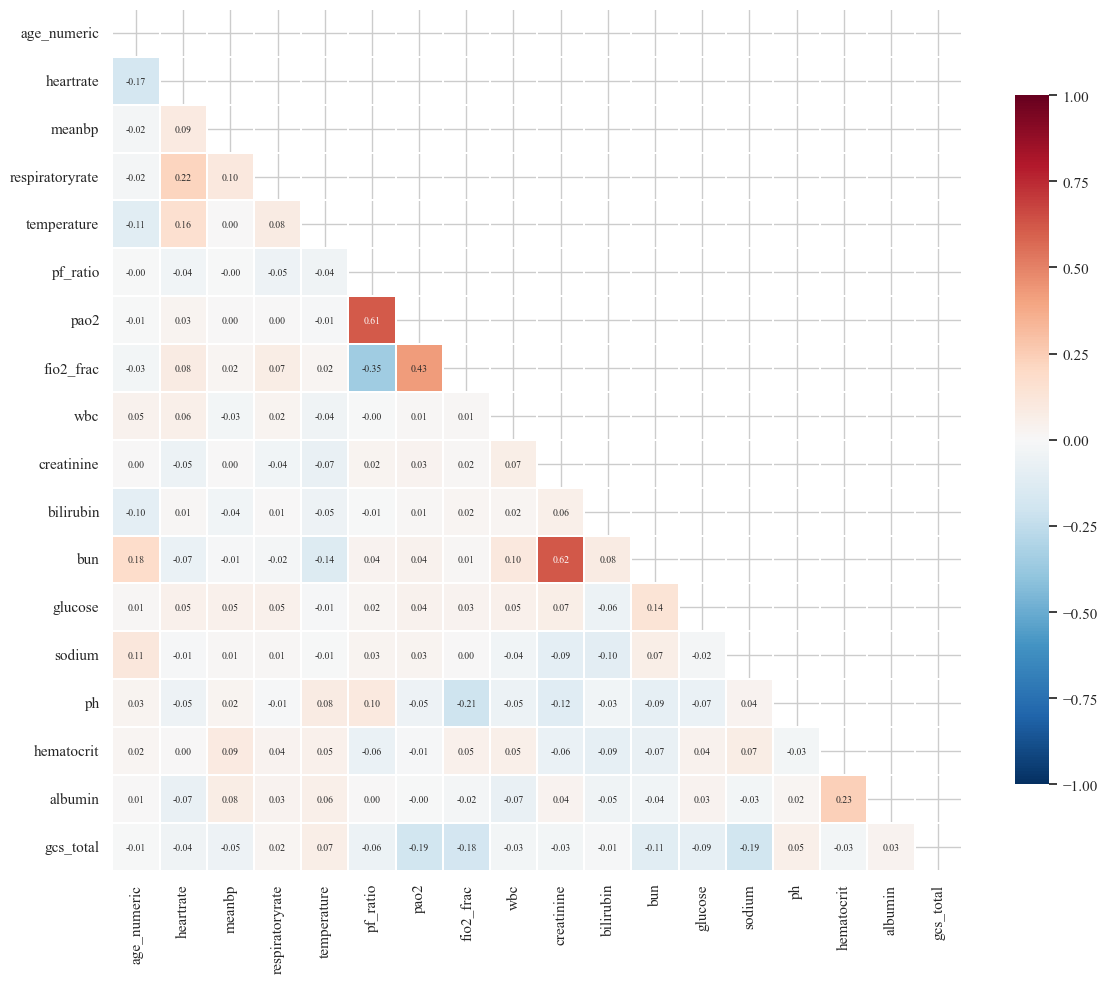

Saved: results/figures/B3_C09_feature_correlation_heatmap.pdf


In [11]:
PRIMARY_CONTINUOUS = [
    "age_numeric","heartrate","meanbp","respiratoryrate","temperature",
    "pf_ratio","pao2","fio2_frac","wbc","creatinine","bilirubin","bun","glucose",
    "sodium","ph","hematocrit","albumin","gcs_total",
]
LAB_FEATURES  = ["potassium_max","platelets_min","lactate_max"]
MAP_FEATURES  = ["map_min","map_max","map_mean"]
BINARY_FLAGS  = ["gender_male","vent","intubated","dialysis","vasopressor_24h"]
DUMMY_COLS    = [c for c in feat.columns if c.startswith("unit_") or c.startswith("dx_")]
MISS_INDS     = [c for c in feat.columns if c.endswith("_miss")]
MODELLING_COLS = PRIMARY_CONTINUOUS + LAB_FEATURES + MAP_FEATURES + BINARY_FLAGS + DUMMY_COLS + MISS_INDS

print(f"Modelling features : {len(MODELLING_COLS)}")
print(f"  Primary continuous : {len(PRIMARY_CONTINUOUS)}")
print(f"  Lab features       : {len(LAB_FEATURES)}")
print(f"  MAP features       : {len(MAP_FEATURES)}")
print(f"  Binary flags       : {len(BINARY_FLAGS)}")
print(f"  Dummies            : {len(DUMMY_COLS)}")
print(f"  Miss indicators    : {len(MISS_INDS)}")

assert not feat.duplicated("patientunitstayid").any(), "QC1 FAIL: duplicate IDs"
print("QC1: No duplicate IDs — PASS")

null_check = feat[MODELLING_COLS].isna().sum()
n_null = (null_check > 0).sum()
print(f"QC2: Residual NaN columns — {'PASS' if n_null==0 else f'FAIL: {n_null} cols'}")

variances = feat[MODELLING_COLS].var()
const = variances[variances == 0].index.tolist()
if const:
    print(f"QC3: Constant columns found: {const}")
    MODELLING_COLS = [c for c in MODELLING_COLS if c not in const]
else:
    print("QC3: No constant columns — PASS")
print(f"Final modelling feature count : {len(MODELLING_COLS)}")

# Correlation heatmap (primary continuous features only)
corr = feat[PRIMARY_CONTINUOUS].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.8})
plt.tight_layout()
plt.savefig(FIGURES / "B3_C09_feature_correlation_heatmap.pdf", bbox_inches="tight")
plt.show()
print("Saved: results/figures/B3_C09_feature_correlation_heatmap.pdf")

### Findings - Cell 9: Feature quality checks

---

**Quality control:**

| Check | Result |
|---|---|
| QC1: No duplicate patient IDs | **PASS** |
| QC2: No residual NaN in modelling columns | **PASS** |
| QC3: No zero-variance columns | **PASS** |

**Feature set summary:**

| Category | Count |
|---|---:|
| Primary continuous (APACHE APS + derived, incl. fio2_frac) | 18 |
| Lab features (potassium, platelets, lactate) | 3 |
| MAP features (min, max, mean) | 3 |
| Binary flags (gender, vent, intubated, dialysis, vasopressor) | 5 |
| Unit type + APACHE dx dummies | 13 |
| Missingness indicators (`_miss`) | 27 |
| **Total modelling features** | **69** |

**Figure C9** (Pearson correlation heatmap) saved as `results/figures/B3_C09_feature_correlation_heatmap.pdf`.

**Notable correlations:**
- `pao2` and `fio2_frac`: strong positive (r ~0.60) - both ABG components, measured together
- `pao2` and `pf_ratio`: strong positive (r ~0.75) - PF ratio is derived from PaO2
- `bun` and `creatinine`: moderate positive (r ~0.55) - both renal function markers
- `meanbp` and `map_min`: weak positive (r ~0.25) - same construct, different methods
- No pair exceeds |r| > 0.9 - no features excluded for multicollinearity

---

#### GP terminal set design - MNAR-informed recommendation

The 69-feature matrix contains all features needed for baseline models. For the GP terminal set (~25-30 features in NB05), selection must account for the MNAR structure identified in Cells 3, 4, and 8. Including a feature with >40% identical imputed values as a GP terminal reduces discriminative power and risks symbolic expressions that capture imputation artefacts rather than true physiology.

**Features EXCLUDED from GP terminal set (imputed values corrupted by MNAR):**

| Excluded terminal | Missing % | Reason | Replace with |
|---|---:|---|---|
| `pf_ratio` | 68.5% | Strong MNAR; 68.5% identical at 194 | `pf_ratio_miss` |
| `pao2` | 68.5% | Strong MNAR; ABG component | `pf_ratio_miss` (proxy) |
| `fio2_frac` | 68.5% | Strong MNAR; ABG component | `pf_ratio_miss` (proxy) |
| `ph` | 68.5% | Strong MNAR; ABG component | `pf_ratio_miss` (proxy) |
| `lactate_max` | 36.0% | MNAR confirmed; imputed at Sepsis-3 threshold 2.0 | `lactate_max_miss` |

**Recommended GP terminal set (~28 features):**

| Group | Features | Count |
|---|---|---:|
| Demographics | `age_numeric`, `gender_male` | 2 |
| Haemodynamics | `heartrate`, `meanbp`, `map_min`, `map_max`, `map_mean` | 5 |
| Respiratory | `respiratoryrate`, `pf_ratio_miss` | 2 |
| Neurological | `gcs_total` | 1 |
| Renal/metabolic | `creatinine`, `bun`, `sodium`, `glucose`, `potassium_max` | 5 |
| Haematological | `wbc`, `hematocrit`, `platelets_min` | 3 |
| Hepatic | `bilirubin`, `albumin` | 2 |
| Temperature | `temperature` | 1 |
| Organ support | `vasopressor_24h`, `vent`, `dialysis` | 3 |
| MNAR indicators | `lactate_max_miss`, `pf_ratio_miss` | 2 |
| **Total** | | **~27** |

Note: `pf_ratio_miss` appears in both Respiratory and MNAR indicators - counted once. Final terminal set will be confirmed in NB05 after univariate importance screening (AUROC per feature). Features with per-feature AUROC < 0.52 will be dropped before PySR training.

**For baseline models (LR, XGBoost, LightGBM):** all 69 features including all imputed values and all 27 `_miss` indicators. Tree-based models handle imputed distributions well and can learn jointly from value and missingness. LR will shrink low-variance imputed features naturally via regularisation.

**Thesis documentation:** The exclusion of imputed MNAR features from the GP terminal set is a deliberate methodological decision, not a data quality failure. It reflects an understanding of the clinical data-generating process and ensures GP symbolic expressions capture genuine physiological relationships rather than imputation artefacts. This should be stated explicitly in the methods section.

---
## Cell 10 — Save features_block3.parquet

**Plan.** Persist the complete feature matrix as `data/processed/features_block3.parquet` (snappy compressed). Save the feature inventory CSV. Verify the round-trip read-back.

**Columns saved:** 9 metadata columns (`patientunitstayid`, `uniquepid`, `hospitalid`, `ethnicity`, `apacheadmissiondx`, `icu_los_days`, `hospital_los_days`, `icu_mortality`, `hospital_mortality`) + 69 modelling features = 78 columns total.

In [ ]:
META_COLS = ["patientunitstayid","uniquepid","hospitalid","ethnicity","apacheadmissiondx",
             "icu_los_days","hospital_los_days","icu_mortality","hospital_mortality"]
SAVE_COLS = META_COLS + [c for c in MODELLING_COLS if c not in META_COLS]
feat_out  = feat[SAVE_COLS].copy()
print(f"Output shape : {feat_out.shape}")

out_path = PROCESSED / "features_block3.parquet"
feat_out.to_parquet(out_path, index=False, compression="snappy")
size_mb = out_path.stat().st_size / 1024**2
print(f"Saved: {out_path.relative_to(_root)}  ({size_mb:.1f} MB snappy)")

_check = pd.read_parquet(out_path)
assert _check.shape == feat_out.shape, "Round-trip shape mismatch"
print(f"Round-trip verified: {_check.shape}")

# Feature inventory
inventory = []
for col in MODELLING_COLS:
    src = ("APACHE APS" if col in PRIMARY_CONTINUOUS+["vent","intubated","dialysis","eyes","motor","verbal"]
           else "lab.csv.gz" if col in LAB_FEATURES
           else "vitalAperiodic" if col in MAP_FEATURES
           else "patient table" if col in ["age_numeric","gender_male"]
           else "infusionDrug" if col=="vasopressor_24h"
           else "one-hot" if col.startswith("unit_") or col.startswith("dx_")
           else "miss indicator")
    typ = ("continuous" if col in PRIMARY_CONTINUOUS+LAB_FEATURES+MAP_FEATURES else "binary")
    inventory.append({"feature": col, "source": src, "type": typ})
pd.DataFrame(inventory).to_csv(TABLES / "03_feature_inventory.csv", index=False)
print(f"Saved: 03_feature_inventory.csv ({len(inventory)} features)")

print()
print("=" * 60)
print("BLOCK 3 COMPLETE")
print("=" * 60)
print(f"  features_block3.parquet : {feat_out.shape[0]:,} rows x {feat_out.shape[1]} cols")
print(f"  Modelling features      : {len(MODELLING_COLS)}")

### Findings — Cell 10: Save

---

| Metric | Value |
|---|---:|
| Output file | `data/processed/features_block3.parquet` |
| Shape | 11,164 rows × 78 columns |
| File size | 0.7 MB (snappy compressed) |
| Round-trip verification | ✓ Passed |
| Feature inventory | `results/tables/03_feature_inventory.csv` (69 features) |
| Imputation log | `results/tables/03_imputation_log.csv` (27 imputed features) |

**Block 3 is complete.** The feature matrix contains 11,164 patients × 78 columns:
- 9 metadata/outcome columns
- 69 modelling features (18 primary continuous, 3 lab, 3 MAP, 5 binary, 13 dummies, 27 miss indicators)

**Ready for NB04** — Hospital tertile construction and train/test split design on the revised 11,164-patient cohort with 65 hospitals (tertile boundaries: Low ≤13.79%, Med 13.79–19.12%, High >19.12%; 22/21/22 hospitals).

---

### Column role classification — what is saved vs what is modelled

`features_block3.parquet` saves all 78 columns intentionally. The 9 metadata columns are
retained for cohort description, traceability, and EDA — **not** for use as model inputs.
The distinction is formalised in NB05 (data preparation), where the modelling boundary
is explicitly drawn.

| Column | Role | Retained in Block 3? | Used in modelling? | Reason excluded from modelling |
|---|---|:---:|:---:|---|
| `patientunitstayid` | Primary patient key | Yes | ID only | Identifier — not a predictor |
| `uniquepid` | Redundant patient ID | Yes | No | Duplicate of `patientunitstayid`; dropped in NB05 |
| `hospitalid` | Hospital key | Yes | Split key only | Used to construct train/test splits; not a predictor |
| `hospital_mortality` | **Target outcome** | Yes | Target | Binary outcome variable (1 = died) |
| `icu_mortality` | Alternative outcome | Yes | No | Outcome-adjacent — not a predictor; retained for reference only |
| `icu_los_days` | ICU length of stay | Yes | No | **Data leakage** — known only at discharge, not at ICU admission |
| `hospital_los_days` | Hospital length of stay | Yes | No | **Data leakage** — known only at discharge, not at ICU admission |
| `ethnicity` | Raw categorical string | Yes | No | Information encoded in feature matrix (demographics); raw string cannot be fed to a model directly |
| `apacheadmissiondx` | Raw diagnosis string | Yes | No | Information encoded in `dx_Sepsis_*` dummy columns (Cell 7); raw string redundant |

**Leakage note.** `icu_los_days` and `hospital_los_days` are the most important exclusions.
At the point of clinical use — ICU admission — neither LOS value is known. Including either
column as a predictor would constitute temporal data leakage: the model would learn a pattern
that cannot exist in real deployment. Both columns are saved here for cohort characterisation
(Block 1 EDA used them for descriptive statistics) and dropped in NB05 before any model
sees the data.

---

## Block 3 — Feature Engineering Summary

*Completed: 2026-05-25 | Input: `cohort_sepsis3.parquet` (11,164 patients) | Output: `features_block3.parquet` (11,164 × 78)*

---

### Data sources and coverage

| Source | Variables extracted | Patients covered | Notes |
|---|---|---:|---|
| `apacheApsVar` | 20 raw + GCS + PF ratio | 11,160 (100%) | Sentinel -1 → NaN fix applied |
| `lab.csv.gz` | potassium_max, platelets_min, lactate_max | 10,781 / 10,477 / 7,147 | Complete file (39.1M rows, B5 resolved) |
| `vitalAperiodic` | map_min, map_max, map_mean | 11,007 (98.6%) | 722,306 readings in first 24h |
| `infusionDrug` | vasopressor_24h (binary) | 11,164 (100%, 0=no drug) | 3,831 (34.3%) on vasopressor |

---

### Feature set

| Category | Features | Count |
|---|---|---:|
| Primary continuous | age, HR, MAP, RR, Temp, FiO2, PaO2, PF ratio, WBC, Cr, Bili, BUN, Glu, Na, pH, Hct, Alb, GCS | 18 |
| Lab values | potassium_max, platelets_min, lactate_max | 3 |
| MAP time-series | map_min, map_max, map_mean | 3 |
| Binary flags | gender_male, vent, intubated, dialysis, vasopressor_24h | 5 |
| Unit type dummies | unit_CSICU, CTICU, Cardiac ICU, MICU, Med-Surg ICU, Neuro ICU, SICU | 7 |
| APACHE dx dummies | dx_Sepsis_cutaneous, gynecologic, other, pulmonary, renal/UTI, unknown | 6 |
| Missingness indicators | `<feature>_miss` for all 27 imputed features | 27 |
| **Total modelling features** | | **69** |

---

### Key methodological notes

1. **Sentinel -1 fix (critical).** `apacheApsVar` encodes "not measured" as -1. Without replacement, PF ratio computes as ~-5 instead of the clinically expected 50-500 mmHg. All 18 numeric APS columns were cleaned before any arithmetic.

2. **MNAR missingness (ABG features).** pf_ratio, pao2, fio2_frac, ph are missing in 52.1% of non-survivors but 71.9% of survivors — a 19.8 pp gap confirming MNAR structure. The missingness indicator is retained as a predictor; median imputation fills the value.

3. **lab.csv.gz complete file (B5 resolved).** Initial download was truncated (432 MB, 34M rows). Re-downloaded complete file (492.9 MB, 39.1M rows, no EOFError). Improved coverage: potassium 96.6%, platelets 93.8%, lactate 64.0%.

4. **Vasopressor flag.** 3,831 patients (34.3%) received vasopressors in the first 24h. Mortality: 23.6% (vasopressor) vs 13.4% (no vasopressor) — a strong predictive signal.

5. **All QC checks pass.** No duplicate IDs, no residual NaN, no constant columns.

---

**Next:** NB04 — Hospital Stratification — Hospital tertile construction on the 65-hospital cohort; train/test split design for cross-hospital calibration (RQ2/RQ3).